#Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Load data

In [ ]:
metabolite_names = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_tissue_name_map.csv')
metabolite_names = metabolite_names.fillna('No_id')
metabolite_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,"1,5-anhydroglucitol (1,5-AG)",No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
1,1-arachidonoyl-GPC (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
2,1-arachidonoyl-GPE (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
3,1-arachidonoyl-GPI (20:4),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
4,1-linoleoylglycerol (18:2),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
...,...,...,...,...,...,...,...,...,...
213,xanthosine,Xanthosine,HMDB0000299,64959.0,18107.0,C01762,3408.0,OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=NC2=C1N=C(...,1
214,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
215,dehydroascorbate,Dehydroascorbic acid,HMDB0001264,440667.0,27956.0,C05422,342.0,[H][C@@]1(OC(=O)C(=O)C1=O)[C@@H](O)CO,1
216,pyruvate,Pyruvic acid,HMDB0000243,1060.0,32816.0,C00022,117.0,CC(=O)C(O)=O,1


In [ ]:
all_hmdb_ids = list(metabolite_names.HMDB.unique())
all_hmdb_ids.remove('No_id')
len(all_hmdb_ids)

200

In [ ]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/total_metabolites_predicted.pkl', 'rb') as file:
  correct_mets = pickle.load(file)

correct_mets_list = []
for i, j in correct_mets.items():
  for k in j:
    correct_mets_list.append(k)

correct_mets_list = list(set(correct_mets_list))
len(correct_mets_list)

70

##Plot metabolites correct vs non-correct

In [ ]:
save_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'

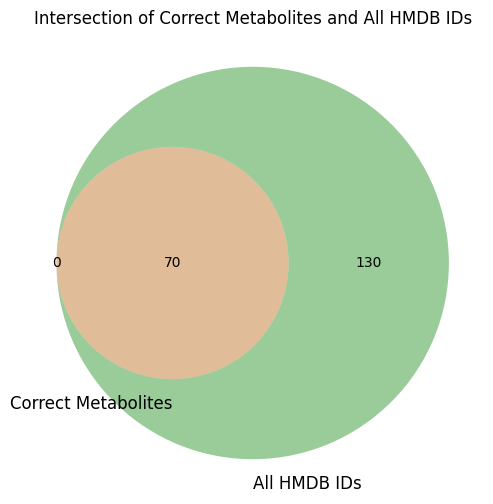

In [ ]:
import os
from matplotlib_venn import venn2


set_correct = set(correct_mets_list)
set_all = set(all_hmdb_ids)

plt.figure(figsize=(8, 6))
venn2([set_correct, set_all], set_labels=('Correct Metabolites', 'All HMDB IDs'))
plt.title('Intersection of Correct Metabolites and All HMDB IDs')
plt.savefig(os.path.join(save_path, 'venn_correct_vs_all.svg'), bbox_inches='tight')
plt.show()

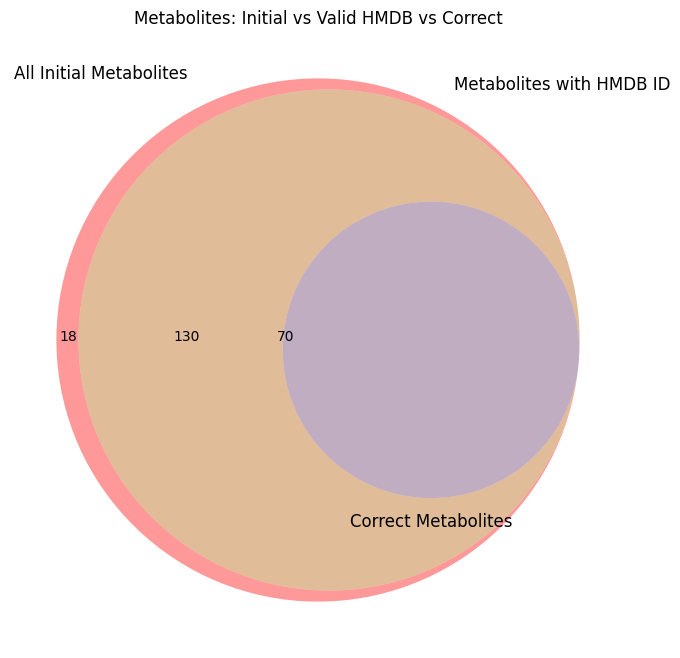

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

plt.figure(figsize=(8, 8))
venn3(subsets=(18, 0, 130, 0, 0, 0, 70),
      set_labels=('All Initial Metabolites', 'Metabolites with HMDB ID', 'Correct Metabolites'))
plt.title('Metabolites: Initial vs Valid HMDB vs Correct')
plt.savefig(os.path.join(save_path, 'venn3_initial_valid_correct.svg'), bbox_inches='tight')
plt.show()

#Overepresentation analysis

##ORA in the combination model metabolites

In [ ]:
set_poor = set_all.difference(set_correct)

print('All: ', len(set_all))
print('Correct: ', len(set_correct))
print('Poor: ', len(set_poor))

All:  200
Correct:  70
Poor:  130


In [ ]:
import os

#Metaboanalyst Overepresentation analysis
ora_correct = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_correct/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
display(ora_correct.head(3))
ora_correct_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_correct_subclass/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
display(ora_correct_subclass.head(3))

ora_poor = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_poor/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
display(ora_poor.head(3))
ora_correct_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_poor_subclass/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
display(ora_correct_subclass.head(3))

,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,Phosphatidylcholine Biosynthesis,14,0.782,4,0.00576,0.565,0.28
1,Arginine and Proline Metabolism,52,2.910,8,0.00626,0.607,0.28
2,Aspartate Metabolism,35,1.960,6,0.01070,1.000,0.28


,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,"Amino acids, peptides, and analogues",3220,1.090,24,6.390000e-26,5.690000e-23,5.690000e-23
1,Carbohydrates and carbohydrate conjugates,1600,0.540,7,1.260000e-06,1.120000e-03,5.590000e-04
2,Fatty acids and conjugates,941,0.319,5,1.830000e-05,1.620000e-02,5.430000e-03


,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,Urea Cycle,28,1.93,9,0.000050,0.00488,0.00488
1,Glycolysis,23,1.58,7,0.000548,0.05310,0.01430
2,Alpha Linolenic Acid and Linoleic Acid Metabolism,17,1.17,6,0.000581,0.05580,0.01430


,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,"Amino acids, peptides, and analogues",3220,2.010,33,2.380000e-30,2.120000e-27,2.120000e-27
1,Fatty acids and conjugates,941,0.587,21,2.340000e-26,2.080000e-23,1.040000e-23
2,Carbohydrates and carbohydrate conjugates,1600,0.994,13,3.290000e-11,2.930000e-08,9.780000e-09


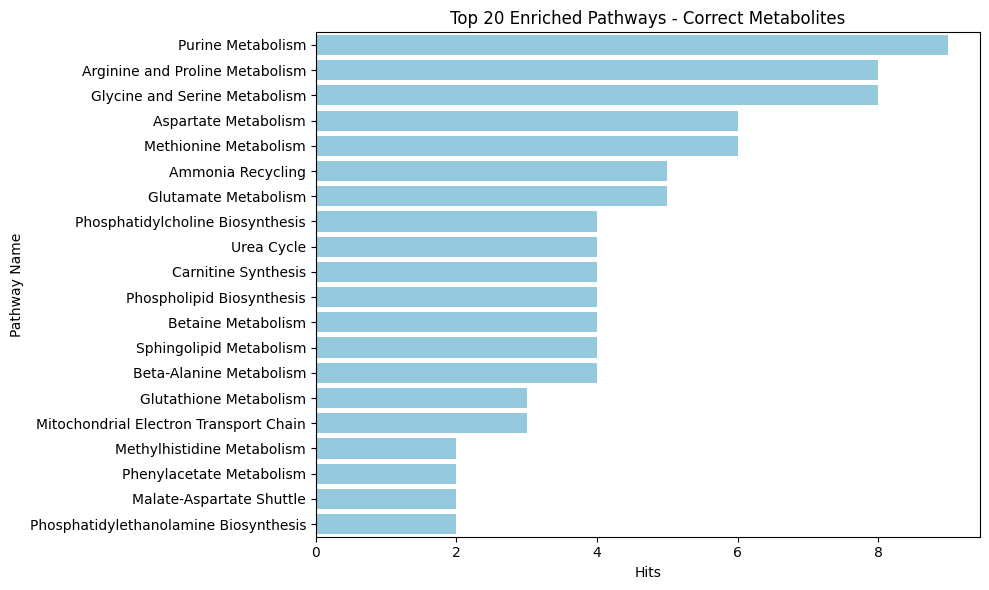

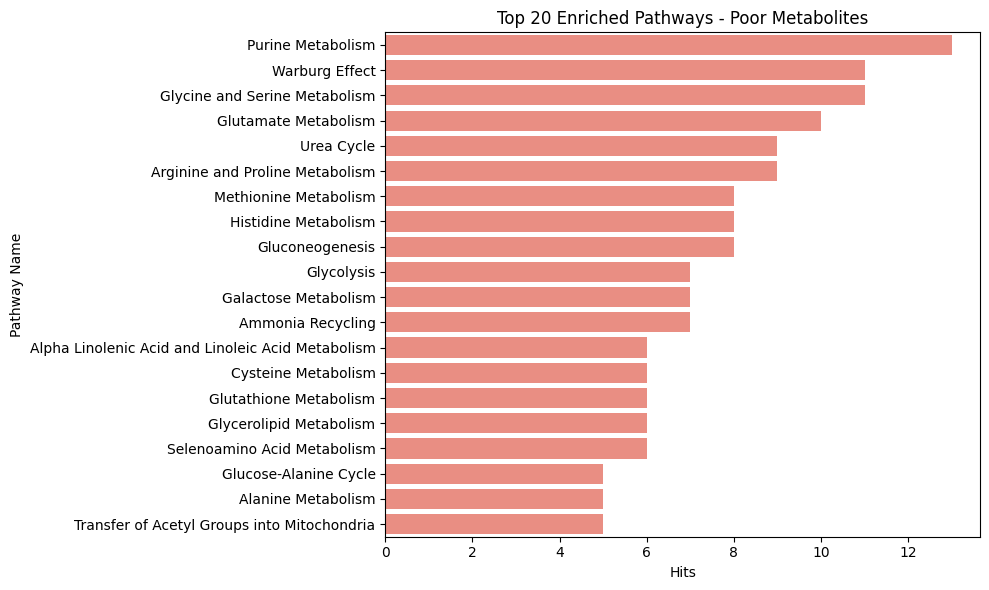

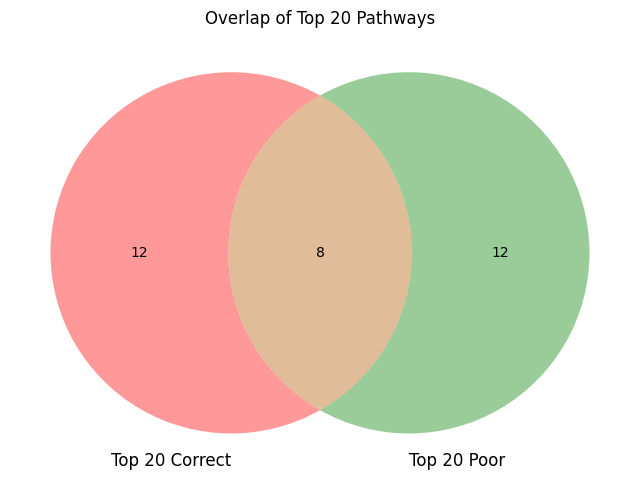

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

top20_correct = ora_correct.head(20).sort_values(by='hits', ascending=False)
top20_poor = ora_poor.head(20).sort_values(by='hits', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(data=top20_correct, x='hits', y='Pathway_name', color='skyblue')
plt.title('Top 20 Enriched Pathways - Correct Metabolites')
plt.xlabel('Hits')
plt.ylabel('Pathway Name')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'top20_pathways_correct.svg'), bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(data=top20_poor, x='hits', y='Pathway_name', color='salmon')
plt.title('Top 20 Enriched Pathways - Poor Metabolites')
plt.xlabel('Hits')
plt.ylabel('Pathway Name')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'top20_pathways_poor.svg'), bbox_inches='tight')
plt.show()


set_top20_correct = set(top20_correct['Pathway_name'])
set_top20_poor = set(top20_poor['Pathway_name'])

plt.figure(figsize=(8, 6))
venn2([set_top20_correct, set_top20_poor], set_labels=('Top 20 Correct', 'Top 20 Poor'))
plt.title('Overlap of Top 20 Pathways')
plt.savefig(os.path.join(save_path, 'venn_top20_pathways_overlap.svg'), bbox_inches='tight')
plt.show()

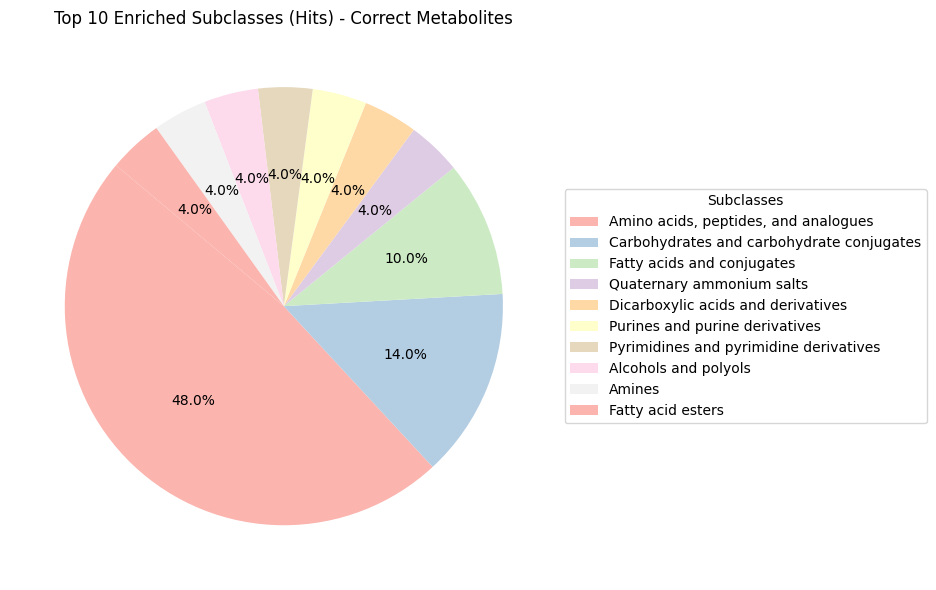

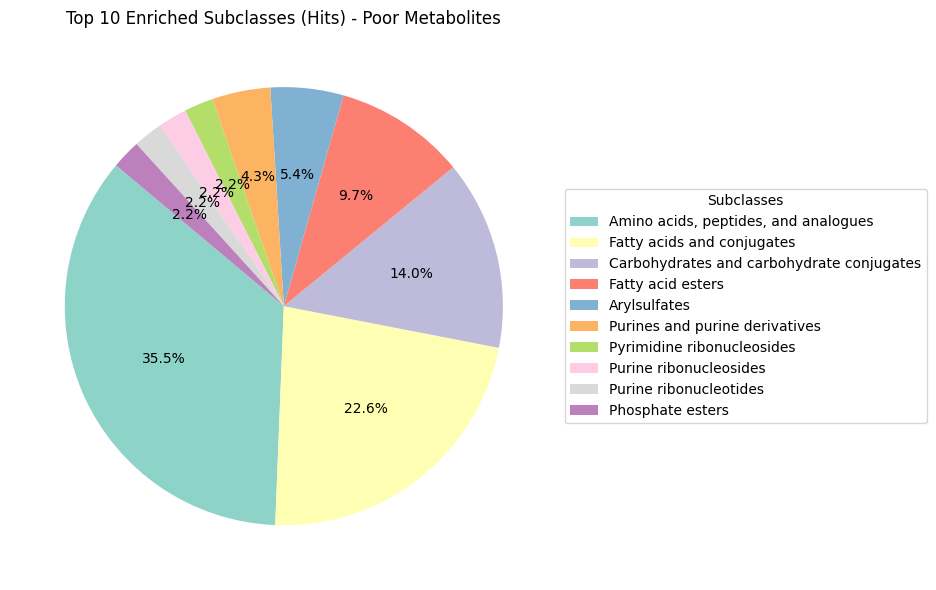

Top Correct Subclass Pathways: {'Quaternary ammonium salts', 'Fatty acids and conjugates', 'Dicarboxylic acids and derivatives', 'Amines', 'Carbohydrates and carbohydrate conjugates', 'Alcohols and polyols', 'Amino acids, peptides, and analogues', 'Purines and purine derivatives', 'Pyrimidines and pyrimidine derivatives', 'Fatty acid esters'}
Top Poor Subclass Pathways: {'Purine ribonucleotides', 'Pyrimidine ribonucleosides', 'Arylsulfates', 'Fatty acids and conjugates', 'Purine ribonucleosides', 'Carbohydrates and carbohydrate conjugates', 'Amino acids, peptides, and analogues', 'Fatty acid esters', 'Purines and purine derivatives', 'Phosphate esters'}
Common Subclass Pathways (Intersection):
- Fatty acids and conjugates
- Carbohydrates and carbohydrate conjugates
- Purines and purine derivatives
- Amino acids, peptides, and analogues
- Fatty acid esters
Number of common subclasses: 5


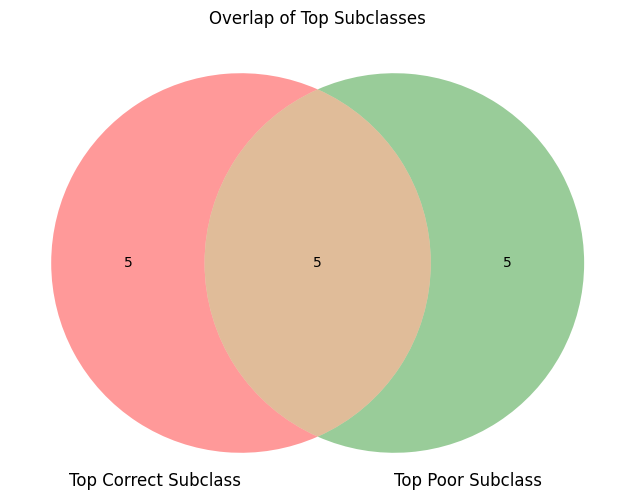

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

save_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'
ora_correct_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_correct_subclass/msea_ora_result.csv')).rename(columns={'Unnamed: 0': 'Pathway_name'})
ora_poor_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_poor_subclass/msea_ora_result.csv')).rename(columns={'Unnamed: 0': 'Pathway_name'})

top10_correct_sub = ora_correct_subclass.sort_values(by='hits', ascending=False).head(10)
top10_poor_sub = ora_poor_subclass.sort_values(by='hits', ascending=False).head(10)


plt.figure(figsize=(10, 6))
patches, texts, autotexts = plt.pie(top10_correct_sub['hits'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.legend(patches, top10_correct_sub['Pathway_name'], title="Subclasses", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Top 10 Enriched Subclasses (Hits) - Correct Metabolites')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'pie_top10_subclass_correct.svg'), bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
patches, texts, autotexts = plt.pie(top10_poor_sub['hits'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.legend(patches, top10_poor_sub['Pathway_name'], title="Subclasses", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Top 10 Enriched Subclasses (Hits) - Poor Metabolites')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'pie_top10_subclass_poor.svg'), bbox_inches='tight')
plt.show()


top_correct_sub = ora_correct_subclass.sort_values(by='hits', ascending=False).head(10)
top_poor_sub = ora_poor_subclass.sort_values(by='hits', ascending=False).head(10)

set_top_correct_sub = set(top_correct_sub['Pathway_name'])
set_top_poor_sub = set(top_poor_sub['Pathway_name'])

print("Top Correct Subclass Pathways:", set_top_correct_sub)
print("Top Poor Subclass Pathways:", set_top_poor_sub)

intersection_subclasses = set_top_correct_sub.intersection(set_top_poor_sub)
print("Common Subclass Pathways (Intersection):")
for item in intersection_subclasses:
    print(f"- {item}")
print(f"Number of common subclasses: {len(intersection_subclasses)}")

plt.figure(figsize=(8, 6))
venn2([set_top_correct_sub, set_top_poor_sub], set_labels=('Top Correct Subclass', 'Top Poor Subclass'))
plt.title('Overlap of Top Subclasses')
plt.savefig(os.path.join(save_path, 'venn_top_subclasses.svg'), bbox_inches='tight')
plt.show()


##ORA in the traditional vs ensemble model metabolites

In [ ]:
#ORA run in Metaboanalyst
ora_ensemble_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_ensemble_subclass/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
ora_dl_subclass = pd.read_csv(os.path.join(save_path, 'ORA_metaboanalyst_res/ORA_dl_subclass/msea_ora_result.csv')).rename(columns = {'Unnamed: 0' : 'Pathway_name'})
display(ora_ensemble_subclass.head(3))
display(ora_dl_subclass.head(3))

,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,"Amino acids, peptides, and analogues",3220,0.727,16,9.340000e-18,8.310000e-15,8.310000e-15
1,Fatty acids and conjugates,941,0.212,5,2.440000e-06,2.160000e-03,1.080000e-03
2,Carbohydrates and carbohydrate conjugates,1600,0.360,4,4.700000e-04,4.170000e-01,1.390000e-01


,Pathway_name,total,expected,hits,Raw p,Holm p,FDR
0,"Amino acids, peptides, and analogues",3220,0.395000,9,9.940000e-11,8.840000e-08,8.840000e-08
1,Quaternary ammonium salts,59,0.007240,2,2.460000e-05,2.190000e-02,1.100000e-02
2,Pyrimidine ribonucleosides,5,0.000613,1,6.130000e-04,5.450000e-01,1.720000e-01


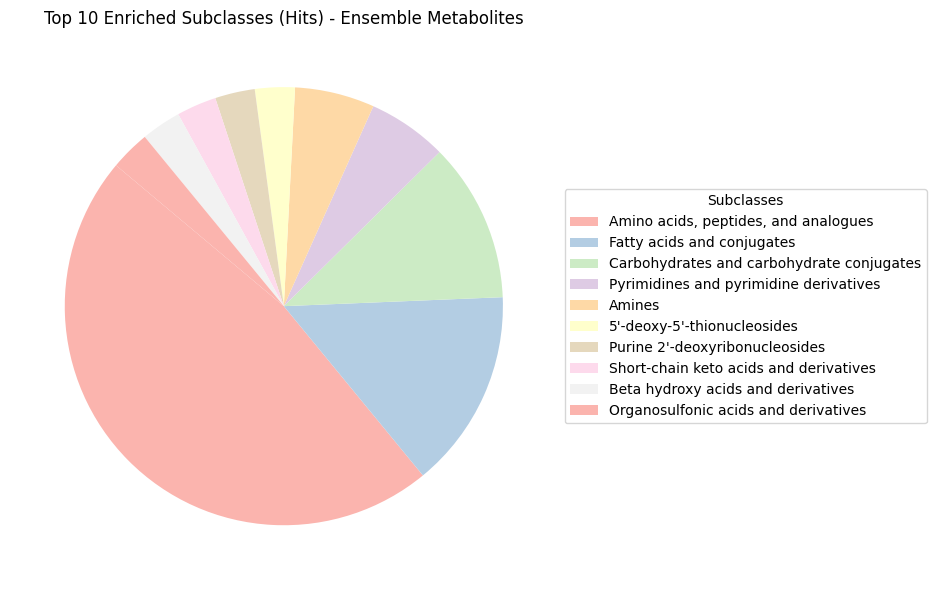

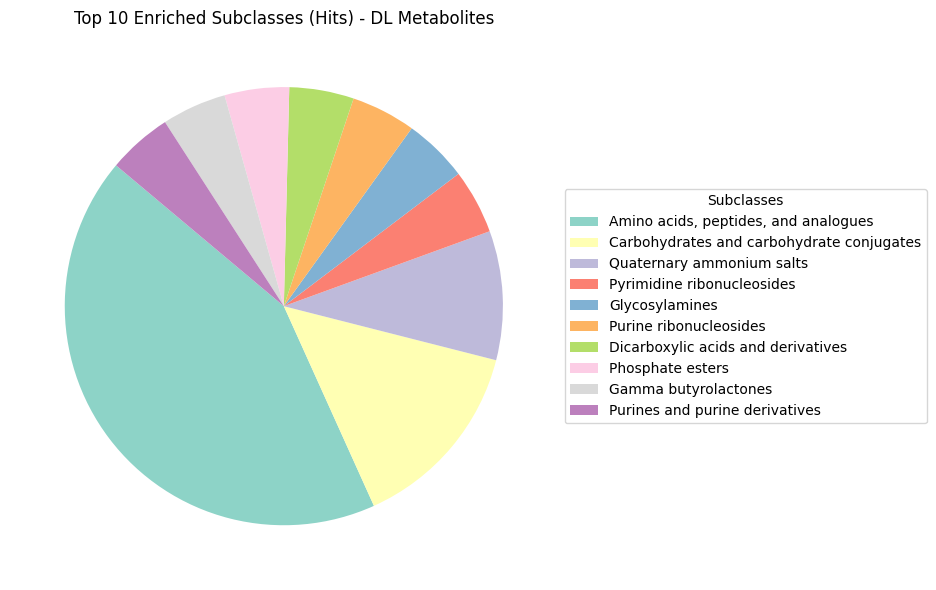

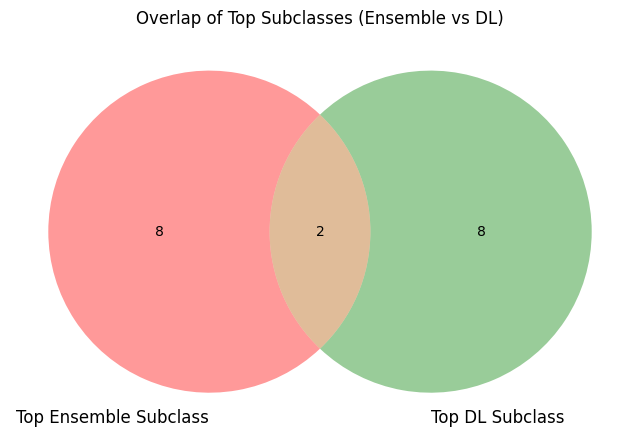

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

top10_ensemble_sub = ora_ensemble_subclass.sort_values(by='hits', ascending=False).head(10)
top10_dl_sub = ora_dl_subclass.sort_values(by='hits', ascending=False).head(10)


plt.figure(figsize=(10, 6))
patches, texts = plt.pie(top10_ensemble_sub['hits'], startangle=140, colors=plt.cm.Pastel1.colors)
plt.legend(patches, top10_ensemble_sub['Pathway_name'], title="Subclasses", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Top 10 Enriched Subclasses (Hits) - Ensemble Metabolites')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'pie_top10_subclass_ensemble.svg'), bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
patches, texts = plt.pie(top10_dl_sub['hits'], startangle=140, colors=plt.cm.Set3.colors)
plt.legend(patches, top10_dl_sub['Pathway_name'], title="Subclasses", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Top 10 Enriched Subclasses (Hits) - DL Metabolites')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'pie_top10_subclass_dl.svg'), bbox_inches='tight')
plt.show()


top_ensemble_sub = ora_ensemble_subclass.sort_values(by='hits', ascending=False).head(10)
top_dl_sub = ora_dl_subclass.sort_values(by='hits', ascending=False).head(10)

set_top_ensemble_sub = set(top_ensemble_sub['Pathway_name'])
set_top_dl_sub = set(top_dl_sub['Pathway_name'])


plt.figure(figsize=(8, 6))
venn2([set_top_ensemble_sub, set_top_dl_sub], set_labels=('Top Ensemble Subclass', 'Top DL Subclass'))
plt.title('Overlap of Top Subclasses (Ensemble vs DL)')
plt.savefig(os.path.join(save_path, 'venn_top_subclasses_ensemble_dl.svg'), bbox_inches='tight')
plt.show()
